In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
import operator
from typing import Annotated, TypedDict, cast

from IPython.display import Image, Markdown, display
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from pydantic import BaseModel, Field


In [ ]:
llm = ChatAnthropic(model="claude-haiku-4-5", temperature=0)
llm_worker = ChatAnthropic(model="claude-haiku-4-5", temperature=0, max_tokens=120)

In [17]:
class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str = Field(
        description=(
            "Brief overview of the main topics and "
            "concepts to be covered in this section"
        )
    )


class Sections(BaseModel):
    sections: list[Section] = Field(description="Sections of the report")


planner = llm.with_structured_output(Sections)

In [18]:
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report:str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [20]:
def orchestrator(state: State):
    report_sections = cast(
        Sections,
        planner.invoke(
            [
                SystemMessage(content="Generate a plan for the report"),
                HumanMessage(content=f"Here is the report topic: {state['topic']}"),
            ]
        ),
    )
    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    section = llm_worker.invoke(
        [
            SystemMessage(
                content=(
                    "Write a report section following the provided name and "
                    "description. Include no preambe. Use markdown formatting."
                )
            ),
            HumanMessage(
                content=f"""Section name: {state["section"].name}
Description: {state["section"].description}
"""
            ),
        ],
    )

    return {"completed_sections":[section.content]}

def synthesizer(state: State):
    return {"final_report": "\n\n---\n\n".join(state["completed_sections"])}

def assign_workers(state: State):
    return [Send("llm_call",{"section": s}) for s in state["sections"]]

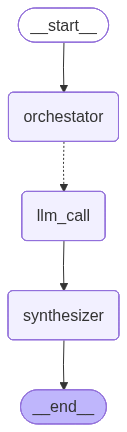

In [21]:
builder = StateGraph(State)

builder.add_node("orchestator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestator")
builder.add_conditional_edges("orchestator", assign_workers, ["llm_call"])
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
result = graph.invoke({"topic": "Create a report on LLM scaling laws"}) #type: ignore
Markdown(result["final_report"])

# Introduction to LLM Scaling Laws

## What Are Scaling Laws?

Scaling laws are empirical relationships that describe how the performance of large language models improves as a function of key resource dimensions. These laws quantify the predictable patterns that emerge when increasing model size, training data volume, or computational resources. Rather than ad-hoc observations, scaling laws provide mathematical frameworks—typically expressed as power laws—that enable researchers and practitioners to forecast model capabilities before training.

The most fundamental scaling law relationship can be expressed as:

**Loss ∝ N^(-α)**

where N represents a scaling dimension (parameters, tokens, or compute) and α is an empirically determined exponent. This inverse power-law relationship indicates that performance improvements follow a consistent, predictable trajectory across multiple orders of magnitude.

## Why Scaling Laws Matter

Scaling laws have become central to modern language model development for several critical reasons:

**Resource Allocation

---

# Historical Development and Key Research

## Early Foundations (2018-2019)

The systematic study of neural network scaling began before the LLM era, with foundational work examining how model performance improves with increased compute, data, and parameters. Early research established that neural networks exhibit predictable power-law relationships between scale and performance, laying groundwork for later LLM-specific investigations.

## The Kaplan et al. Breakthrough (2020)

OpenAI's seminal paper "Scaling Laws for Neural Language Models" (Kaplan et al., 2020) marked a watershed moment in the field. This work provided the first comprehensive empirical characterization of scaling laws specifically for language models, establishing that:

- Loss follows a power-law relationship with model size, dataset size, and compute budget
- Three separate scaling laws govern performance improvements across these dimensions
- Optimal allocation of compute requires balancing model size and training

---

# Scaling Dimensions: Parameters, Data, and Compute

## Overview

Modern machine learning systems scale along three interdependent dimensions: model parameters, training data volume, and computational resources. Understanding how each dimension affects performance and how they interact is fundamental to optimizing model development and deployment strategies.

## Model Parameters

### Definition and Scope

Model parameters represent the learnable weights and biases that define a neural network's capacity. Parameter count directly determines:

- **Model capacity**: The complexity of functions the model can represent
- **Memory requirements**: Storage needed for weights during training and inference
- **Computational cost**: Operations required for forward and backward passes

### Performance Relationships

**Scaling laws for parameters** demonstrate that model performance improves predictably with parameter count, following a power-law relationship:

$$L(N) = aN^{-\alpha}$$

where loss $L$ decreases as parameters $N$ increase,

---

# Empirical Scaling Laws and Mathematical Models

## Overview of Scaling Laws

Scaling laws describe the relationship between model performance and key variables such as model size (parameters), dataset size (tokens), and compute budget. These empirical relationships have become fundamental to understanding deep learning systems and predicting their capabilities before training.

## Power-Law Relationships

The most common form of scaling laws follows a power-law structure:

$$L(N) = aN^{-\alpha} + \epsilon$$

where:
- $L(N)$ is the loss (or error) as a function of model size
- $N$ is the number of parameters
- $\alpha$ is the scaling exponent (typically 0.07-0.1 for language models)
- $a$ is a constant coefficient
- $\epsilon$ represents irreducible error

Similar power-law relationships exist for dataset size $D$

---

# Optimal Allocation of Resources

## Introduction to Resource Allocation in Model Training

Training large language models requires substantial computational investment across multiple dimensions: model parameters, training data volume, and compute cycles. The allocation of these resources significantly impacts both model performance and training efficiency. Understanding optimal allocation strategies enables practitioners to maximize model quality within fixed computational budgets.

## The Chinchilla Optimal Ratio

### Foundational Research

The Chinchilla scaling laws, introduced by DeepMind researchers, established empirical relationships between model size, dataset size, and compute budget. The key finding challenges earlier assumptions that model size should dominate resource allocation decisions.

**Core Principle**: For a fixed compute budget, optimal performance is achieved when model size and training data volume are scaled proportionally, rather than heavily favoring one dimension.

### The Optimal Ratio

The Chinchilla research demonstrated that the compute-optimal allocation follows approximately:

- **Model

---

# Emergent Abilities and Scaling Phenomena

## Overview

Emergent abilities represent a fundamental characteristic of large language models where new capabilities appear suddenly at certain scales rather than improving gradually with model size. These phenomena challenge traditional scaling assumptions and reveal qualitatively different behaviors across the model size spectrum.

## Grokking and Sudden Capability Emergence

Emergent abilities manifest as sharp transitions in model performance across specific tasks. Rather than smooth improvement curves, many capabilities exhibit threshold effects where models below a certain scale perform near-random, while models above that threshold demonstrate competent performance.

Key observations include:
- **Task-dependent thresholds**: Different abilities emerge at different model scales, suggesting distinct complexity requirements
- **Unpredictability**: Emergence patterns are difficult to predict a priori, complicating scaling law extrapolation
- **Irreversibility**: Once emerged, capabilities generally persist and improve with further scaling

Examples of

---

# Practical Applications and Industry Implications

## Model Development and Training Strategy

Organizations leverage scaling law insights to make informed decisions about model architecture and training procedures. By understanding how performance scales with model size, data volume, and compute, teams can optimize their development pipelines before committing substantial resources.

**Compute-Optimal Training**: Scaling laws enable practitioners to determine the optimal balance between model parameters and training tokens. Rather than defaulting to larger models with fewer training steps, organizations now use empirical scaling relationships to allocate compute budgets efficiently. This has led to the development of smaller, more efficient models that match or exceed the performance of larger predecessors trained on insufficient data.

**Architecture Selection**: Scaling law predictions inform decisions about which architectural innovations to pursue. Teams can estimate whether a proposed modification will yield meaningful improvements across different scales, helping prioritize research directions with the highest expected returns.

## Cost-Benefit Analysis and Budget Allocation

Scaling laws provide

---

# Limitations and Open Questions

## Current Understanding Gaps

Despite significant progress in characterizing scaling laws, fundamental questions remain about their underlying mechanisms. The precise relationship between model architecture, training dynamics, and emergent capabilities is not fully understood. While empirical scaling laws provide predictive power, they offer limited insight into *why* these relationships hold or what architectural principles might enable more efficient scaling.

The theoretical foundations of scaling laws remain underdeveloped. Current explanations rely heavily on information-theoretic arguments and statistical learning theory, but these frameworks do not fully account for the discrete, combinatorial nature of language or the role of inductive biases in neural networks. A more rigorous mathematical theory connecting optimization dynamics to scaling behavior would substantially advance the field.

## Potential Breaking Points

Several factors could invalidate or substantially modify existing scaling laws:

**Architectural innovations**: Current scaling laws assume transformer-based architectures. Novel architectures with fundamentally different inductive bi

---

# Future Directions and Research Frontiers

## Emerging Research Areas

The landscape of scaling research is rapidly expanding beyond traditional parameter and data scaling. Several promising directions are gaining momentum:

**Architectural Innovation and Scaling**: While transformer architectures have dominated recent scaling studies, emerging architectures (state-space models, mixture-of-experts variants, and hybrid approaches) present opportunities to understand how scaling laws generalize across different computational paradigms. Research into whether fundamental scaling relationships hold architecture-agnostically remains largely open.

**Efficiency-Centric Scaling**: Growing emphasis on compute-efficient scaling has spawned new research directions examining inference scaling, sparse scaling, and dynamic computation allocation. Understanding how to achieve equivalent performance with fewer resources represents a critical frontier as deployment constraints become increasingly important.

**Interpretability and Scaling**: The relationship between model scale and interpretability remains poorly understood. Investigating how scaling affects mechanistic properties, feature emergence, and internal representations

---

# Conclusion and Key Takeaways

## Summary of Critical Insights

LLM scaling laws represent one of the most significant empirical discoveries in modern AI research. The consistent power-law relationships between model size, training data, and compute resources have fundamentally reshaped our understanding of how language models improve. These laws demonstrate that performance gains are predictable and reproducible across different architectures and domains, providing a scientific foundation for AI development that was previously lacking.

The evidence overwhelmingly shows that larger models trained on more data with greater computational resources consistently achieve better performance across diverse benchmarks. This relationship holds across multiple orders of magnitude, suggesting that we have not yet reached fundamental limits in model scaling. The emergence of novel capabilities at scale—from in-context learning to chain-of-thought reasoning—indicates that scaling may unlock qualitatively different modes of intelligence.

## Significance for Future AI Development

Scaling laws have profound implications for the trajectory of AI

In [23]:
for s in result["sections"]:
    print(f" -{s.name}")
print(f"\nTotal sections witten: {len(result['completed_sections'])}")

 -Introduction to LLM Scaling Laws
 -Historical Development and Key Research
 -Scaling Dimensions: Parameters, Data, and Compute
 -Empirical Scaling Laws and Mathematical Models
 -Optimal Allocation of Resources
 -Emergent Abilities and Scaling Phenomena
 -Practical Applications and Industry Implications
 -Limitations and Open Questions
 -Future Directions and Research Frontiers
 -Conclusion and Key Takeaways

Total sections witten: 10
